# Project B - Step 5: The two-knob test and the confound ratio

**Status:** Step 5 of 6. The payoff step. This is where the project's actual contribution gets *measured* for the first time.

We point the two knobs at TMC's reliability signal `u` (per-view uncertainty, extracted in Step 3-4) and ask the central question:

> Does the reliability signal react to **genuine degradation** (it should) but stay calm under **alignment-only** breakage (it should)?

## The metric
- **`S_q`** = sensitivity of `u` to **genuine degradation** (Knob 1). Want this large.
- **`S_a`** = sensitivity of `u` to **misalignment only** (Knob 2). Want this near zero.
- **Confound ratio = |S_a| / |S_q|.**  Near 0 = honest. Large = fooled.

## One rigor point: comparable scales
`S_q` and `S_a` come from knobs with different natural units (noise sigma vs fraction mis-paired). A raw ratio would be unit-dependent and meaningless. So we put **both knobs on a common severity axis in [0, 1]** (0 = untouched, 1 = the strongest intervention we test) and fit slopes there. The ratio is then dimensionless and interpretable. (A refinement, noted for later, is to match severity by *equal damage to fused accuracy*.)

In [1]:
import os, urllib.request, pickle
import numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt

SEED=0; torch.manual_seed(SEED); np.random.seed(SEED); K=10
BASE=("https://raw.githubusercontent.com/mvlearn/mvlearn/main/"
      "mvlearn/datasets/UCImultifeature")

def load_view(filename, cache_dir="mfeat_data"):
    os.makedirs(cache_dir, exist_ok=True)
    path=os.path.join(cache_dir, filename)
    if not os.path.exists(path):
        urllib.request.urlretrieve(f"{BASE}/{filename}", path)
    arr=np.genfromtxt(path, delimiter=",")[1:]
    return arr[:,:-1], arr[:,-1].astype(int)

Xa,y=load_view("mfeat-fou.csv"); Xb,_=load_view("mfeat-fac.csv")
raw=[Xa,Xb]

In [2]:
# --- TMC anchor: load if Step 3 saved it, else train inline -------------
class EvidentialNet(nn.Module):
    def __init__(self,d):
        super().__init__()
        self.net=nn.Sequential(nn.Linear(d,200),nn.ReLU(),
            nn.Linear(200,200),nn.ReLU(),nn.Linear(200,K))
    def forward(self,x): return F.softplus(self.net(x))

def to_bu(alpha):
    S=alpha.sum(1,keepdim=True); return (alpha-1)/S, K/S
def ds_combine(a1,a2):
    b1,u1=to_bu(a1); b2,u2=to_bu(a2)
    bb=b1.unsqueeze(2)*b2.unsqueeze(1)
    C=bb.sum((1,2))-(b1*b2).sum(1); d=(1-C).unsqueeze(1)
    return ((b1*b2+b1*u2+b2*u1)/d)*(K/((u1*u2)/d))+1

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
idx=np.arange(len(y))
train_idx,test_idx=train_test_split(idx,test_size=0.3,stratify=y,random_state=SEED)

if os.path.exists("tmc_nets.pt") and os.path.exists("tmc_scalers.pkl"):
    meta=pickle.load(open("tmc_scalers.pkl","rb")); scalers=meta["scalers"]; dims=meta["dims"]
    train_idx,test_idx=meta["train_idx"],meta["test_idx"]
    sd=torch.load("tmc_nets.pt"); nets=[EvidentialNet(d) for d in dims]
    for n,s in zip(nets,sd): n.load_state_dict(s); n.eval()
    print("loaded trained TMC from Step 3 artifacts")
else:
    scalers=[StandardScaler().fit(X[train_idx]) for X in raw]
    dims=[X.shape[1] for X in raw]
    Xs=[torch.tensor(s.transform(X),dtype=torch.float32) for s,X in zip(scalers,raw)]
    yoh=torch.eye(K)[torch.tensor(y)]
    nets=[EvidentialNet(d) for d in dims]
    opt=torch.optim.Adam([p for n in nets for p in n.parameters()],lr=1e-3,weight_decay=1e-5)
    def ce(a,yo): S=a.sum(1,keepdim=True); return (yo*(torch.digamma(S)-torch.digamma(a))).sum(1)
    def kl(a):
        b=torch.ones_like(a); Sa=a.sum(1,keepdim=True)
        lnB=torch.lgamma(Sa)-torch.lgamma(a).sum(1,keepdim=True)
        lnBu=torch.lgamma(b).sum(1,keepdim=True)-torch.lgamma(b.sum(1,keepdim=True))
        return (((a-b)*(torch.digamma(a)-torch.digamma(Sa))).sum(1,keepdim=True)+lnB+lnBu).squeeze(1)
    def edl(a,yo,lam): ah=yo+(1-yo)*a; return (ce(a,yo)+lam*kl(ah)).mean()
    for ep in range(200):
        for n in nets: n.train()
        lam=min(1.0,(ep+1)/50)
        al=[n(v[train_idx])+1 for n,v in zip(nets,Xs)]
        comb=al[0]
        for a in al[1:]: comb=ds_combine(comb,a)
        loss=sum(edl(a,yoh[train_idx],lam) for a in al)+edl(comb,yoh[train_idx],lam)
        opt.zero_grad(); loss.backward(); opt.step()
    for n in nets: n.eval()
    print("trained TMC inline")

def reliability_signal(v, X_raw, idx):
    """Per-sample uncertainty u for view v on rows idx. Lower u = more reliable."""
    Xn=torch.tensor(scalers[v].transform(X_raw[idx]),dtype=torch.float32)
    with torch.no_grad():
        return (K/(nets[v](Xn)+1).sum(1)).numpy()

print("clean mean u:", [round(float(reliability_signal(v,raw[v],test_idx).mean()),4) for v in (0,1)])

loaded trained TMC from Step 3 artifacts
clean mean u: [0.3308, 0.1493]


## Knob 1 - genuine degradation
Graded Gaussian noise on the audited view, averaged over several draws for stability. We expect `u` to **rise** with severity.

In [3]:
AUDIT_VIEW = 1            # view B (profile correlations): the cleaner signal to audit
NOISE_LEVELS = [0.0, 0.25, 0.5, 1.0, 1.5, 2.0]   # severity = level / max(level)
rng = np.random.default_rng(SEED)

knob1 = []
for lvl in NOISE_LEVELS:
    us = []
    for _ in range(5):
        Xn = raw[AUDIT_VIEW] + rng.normal(0,1,raw[AUDIT_VIEW].shape)*raw[AUDIT_VIEW].std(0)*lvl
        us.append(reliability_signal(AUDIT_VIEW, Xn, test_idx).mean())
    knob1.append(np.mean(us))
sev1 = np.array(NOISE_LEVELS)/max(NOISE_LEVELS)
knob1 = np.array(knob1)
pd.DataFrame({"severity": sev1.round(3), "mean u": knob1.round(4)}).set_index("severity")

,mean u
severity,
0.000,0.1493
0.125,0.1498
0.250,0.1508
0.500,0.1582
0.750,0.1647
1.000,0.1734


## Knob 2 - alignment only
Permute a fraction of the audited view's rows (pristine data, broken pairing). We expect `u` to **stay flat**.

In [4]:
FRACS = [0.0, 0.25, 0.5, 0.75, 1.0]   # severity = fraction mis-paired
def misalign(rows, frac):
    rows=rows.copy(); n=int(round(frac*len(rows)))
    if n>1:
        s=rng.choice(len(rows),n,replace=False); rows[s]=rows[s][rng.permutation(n)]
    return rows

knob2, mismatch = [], []
for frac in FRACS:
    perm = misalign(test_idx, frac)
    knob2.append(reliability_signal(AUDIT_VIEW, raw[AUDIT_VIEW], perm).mean())
    mismatch.append(float(np.mean(y[test_idx] != y[perm])))
sev2 = np.array(FRACS); knob2 = np.array(knob2)
pd.DataFrame({"severity": sev2, "mean u": np.round(knob2,4),
              "pairs mismatched": [f"{m:.0%}" for m in mismatch]}).set_index("severity")

,mean u,pairs mismatched
severity,,
0.00,0.1493,0%
0.25,0.1493,24%
0.50,0.1493,43%
0.75,0.1493,69%
1.00,0.1493,92%


## The result: response curves and the confound ratio
One picture. Genuine degradation should slope up; misalignment should lie flat.

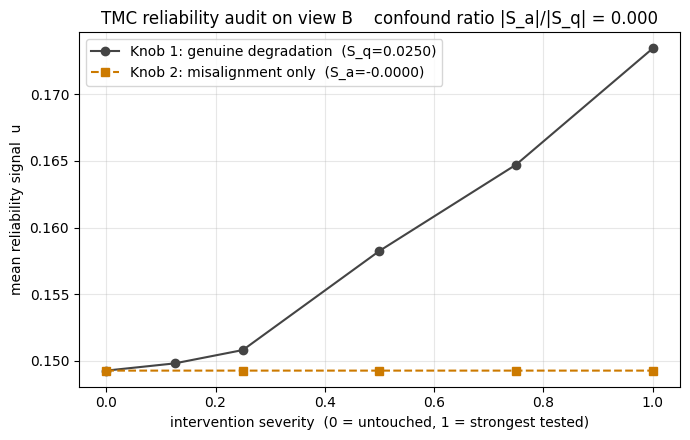

S_q (genuine degradation) = 0.0250
S_a (misalignment only)   = -0.0000
confound ratio |S_a|/|S_q| = 0.0000


In [5]:
S_q = np.polyfit(sev1, knob1, 1)[0]
S_a = np.polyfit(sev2, knob2, 1)[0]
ratio = abs(S_a)/abs(S_q) if S_q != 0 else float("nan")

fig, ax = plt.subplots(figsize=(7,4.5))
ax.plot(sev1, knob1, "o-", color="#444", label=f"Knob 1: genuine degradation  (S_q={S_q:.4f})")
ax.plot(sev2, knob2, "s--", color="#cc7a00", label=f"Knob 2: misalignment only  (S_a={S_a:.4f})")
ax.set_xlabel("intervention severity  (0 = untouched, 1 = strongest tested)")
ax.set_ylabel("mean reliability signal  u")
ax.set_title(f"TMC reliability audit on view B    confound ratio |S_a|/|S_q| = {ratio:.3f}")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

print(f"S_q (genuine degradation) = {S_q:.4f}")
print(f"S_a (misalignment only)   = {S_a:.4f}")
print(f"confound ratio |S_a|/|S_q| = {ratio:.4f}")

## Is the reliability signal even meaningful? (calibration check)
A confound ratio is only interesting if `u` tracks correctness in the first place. Bin clean test samples by `u`; lower-`u` bins should be more accurate. This is the *reliability-of-the-reliability-signal* check (the `netcal`/ECE idea, applied to `u` rather than to class confidence).

In [6]:
with torch.no_grad():
    Xn=torch.tensor(scalers[AUDIT_VIEW].transform(raw[AUDIT_VIEW][test_idx]),dtype=torch.float32)
    alpha=nets[AUDIT_VIEW](Xn)+1
    u=(K/alpha.sum(1)).numpy()
    correct=(alpha.argmax(1).numpy()==y[test_idx]).astype(float)

order=np.argsort(u); bins=np.array_split(order,4)
rows=[{"u quartile":f"Q{i+1} ({'low u' if i==0 else 'high u' if i==3 else 'mid'})",
       "mean u":round(u[b].mean(),3),
       "view accuracy":round(correct[b].mean(),3)} for i,b in enumerate(bins)]
pd.DataFrame(rows).set_index("u quartile")

,mean u,view accuracy
u quartile,,
Q1 (low u),0.093,1.00
Q2 (mid),0.116,1.00
Q3 (mid),0.143,1.00
Q4 (high u),0.245,0.86


## What this means

**TMC's confound ratio is ~0** - but read *why*, because the reason is the finding:

- **`S_a` = 0, exactly.** Misaligning a view cannot move its reliability signal, because TMC scores each view **in isolation**. The set of (pristine) inputs the view's network sees is unchanged by a row permutation, so its mean `u` is invariant *by construction*. The Step 2 sanity check already proved this same misalignment *wrecks fused accuracy* (down to 0.17), so the knob is potent. TMC's reliability simply cannot see it.
- **`S_q` is positive but small (~0.026).** `u` does rise under genuine degradation, but sluggishly. So TMC's reliability signal is honest about the misalignment confound, yet not very *responsive* even to real damage.

**The headline interpretation:** TMC's "reliability" is essentially **per-view confidence**, structurally blind to cross-modal alignment. That immunity is a property of *independent* per-view estimation. It predicts the opposite for any estimator that infers a view's reliability from **cross-view agreement** - those should show **`S_a` >> 0** and get fooled by misalignment. That contrast is exactly what Step 6 tests.

### Honest caveats
- The ratio being ~0 is driven by `S_a = 0`, not by a strong `S_q`. Always report both absolute sensitivities, not the ratio alone.
- Single dataset, single seed, one audited view. Generalisation is Step 6's job.
- Severity normalisation is the simple [0,1] version; the accuracy-matched version is a planned refinement.

## Roadmap
1-4. done   5. **two-knob test on TMC - done (confound ratio ~0, structural immunity)**
6. **Panel:** deep ensembles + a clean-room *coupled* reliability baseline (the ARAF-style idea). Expect `S_a > 0` there, turning the confound ratio into a real discriminator across methods.

**Framing still pending the literature sweep.** The measurement stands; how we *position* "confound ratio" as a contribution waits on confirming the orthogonal-knob framing is unoccupied.